# **Notebook : Cleaning et Analyse Exploratoire des Données (EDA)**
**Objectif global:**
Ce notebook a pour objectif de nettoyer, préparer et analyser exploratoirement les données issues des annonces automobiles (Avito), afin de produire un dataset final propre et exploitable pour les étapes de feature engineering et de modélisation.

# Partie 1 : Importation des bibliothèques
Rôle :
*   Manipulation et transformation des données (`pandas`, `numpy`)

*   Visualisation et analyse exploratoire (`matplotlib`, `seaborn`)

*   Encodage des variables catégorielles (`OneHotEncoder`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


# Style des graphiques
sns.set_style("whitegrid")

ModuleNotFoundError: No module named 'seaborn'

# Partie 2 : Chargement et inspection initiale des données
**Objectif :**

*   Comprendre la structure du dataset

*   Identifier les types de variables

*   Repérer les valeurs manquantes et incohérences

In [ ]:
# Charger le dataset
df = pd.read_csv("avitoo.csv", encoding='utf-8')
df

,Prix,Titre,Année-Modèle,Boite de vitesses,Type de carburant,Kilométrage,Marque,Modèle,Puissance fiscale,Équipements,Nombre de portes,Origine,Première main,État
0,78 000 DH,Sandero avec clim,2018,Manuelle,Essence,170 000 - 179 999,Dacia,Sandero,7 CV,"ABS, Airbags, CD/MP3/Bluetooth, Climatisation,...",NaN,NaN,NaN,NaN
1,100 000 DH,Megane 3 à vendre,2010,Manuelle,Diesel,160 000 - 169 999,Renault,Megane,6 CV,"Climatisation, Limiteur de vitesse, Ordinateur...",5.0,WW au Maroc,Oui,Très bon
2,NaN,Dacia Dokker Diesel Manuelle 2019 à Rabat,2020,Manuelle,Diesel,70 000 - 74 999,Dacia,Dokker,6 CV,"Airbags, CD/MP3/Bluetooth, Climatisation, Limi...",5.0,WW au Maroc,Oui,Excellent
3,155 000 DH,Dacia Logan Diesel Manuelle 2022 à Agadir,2022,Manuelle,Diesel,30 000 - 34 999,Dacia,Logan,6 CV,"ABS, Airbags, CD/MP3/Bluetooth, Caméra de recu...",5.0,WW au Maroc,Oui,Excellent
4,120 000 DH,Skoda Rapid Diesel Manuelle 2015 à Kénitra,2015,Manuelle,Diesel,180 000 - 189 999,Skoda,Rapid,6 CV,"ABS, Airbags, CD/MP3/Bluetooth, Climatisation,...",5.0,WW au Maroc,Oui,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47583,345 000 DH,santafe 2021,2021,Automatique,Diesel,45 000 - 49 999,Hyundai,Santa Fe,9 CV,"ABS, Airbags, Caméra de recul, Climatisation, ...",5.0,WW au Maroc,NaN,Excellent
47584,NaN,Hyundai i30,2015,Automatique,Diesel,15 000 - 19 999,Hyundai,i30,6 CV,Aucun,5.0,WW au Maroc,Non,Neuf
47585,NaN,Peugeot 208 Diesel Manuelle 2016 à Kénitra,2016,Manuelle,Diesel,150 000 - 159 999,Peugeot,208,10 CV,Aucun,NaN,NaN,NaN,Très bon
47586,110 000 DH,Opel Insignia 2012 Toute Option Automatique 2....,2012,Automatique,Diesel,190 000 - 199 999,Opel,Insignia,8 CV,"ABS, Airbags, CD/MP3/Bluetooth, Caméra de recu...",5.0,WW au Maroc,Non,Très bon


In [ ]:
df.shape

(47588, 14)

In [ ]:
df.head()

,Prix,Titre,Année-Modèle,Boite de vitesses,Type de carburant,Kilométrage,Marque,Modèle,Puissance fiscale,Équipements,Nombre de portes,Origine,Première main,État
0,78 000 DH,Sandero avec clim,2018,Manuelle,Essence,170 000 - 179 999,Dacia,Sandero,7 CV,"ABS, Airbags, CD/MP3/Bluetooth, Climatisation,...",NaN,NaN,NaN,NaN
1,100 000 DH,Megane 3 à vendre,2010,Manuelle,Diesel,160 000 - 169 999,Renault,Megane,6 CV,"Climatisation, Limiteur de vitesse, Ordinateur...",5.0,WW au Maroc,Oui,Très bon
2,NaN,Dacia Dokker Diesel Manuelle 2019 à Rabat,2020,Manuelle,Diesel,70 000 - 74 999,Dacia,Dokker,6 CV,"Airbags, CD/MP3/Bluetooth, Climatisation, Limi...",5.0,WW au Maroc,Oui,Excellent
3,155 000 DH,Dacia Logan Diesel Manuelle 2022 à Agadir,2022,Manuelle,Diesel,30 000 - 34 999,Dacia,Logan,6 CV,"ABS, Airbags, CD/MP3/Bluetooth, Caméra de recu...",5.0,WW au Maroc,Oui,Excellent
4,120 000 DH,Skoda Rapid Diesel Manuelle 2015 à Kénitra,2015,Manuelle,Diesel,180 000 - 189 999,Skoda,Rapid,6 CV,"ABS, Airbags, CD/MP3/Bluetooth, Climatisation,...",5.0,WW au Maroc,Oui,Excellent


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47588 entries, 0 to 47587
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Prix               34834 non-null  object 
 1   Titre              47522 non-null  object 
 2   Année-Modèle       47240 non-null  object 
 3   Boite de vitesses  47209 non-null  object 
 4   Type de carburant  47294 non-null  object 
 5   Kilométrage        47218 non-null  object 
 6   Marque             47216 non-null  object 
 7   Modèle             47216 non-null  object 
 8   Puissance fiscale  47284 non-null  object 
 9   Équipements        47588 non-null  object 
 10  Nombre de portes   41380 non-null  float64
 11  Origine            41396 non-null  object 
 12  Première main      40349 non-null  object 
 13  État               45328 non-null  object 
dtypes: float64(1), object(13)
memory usage: 5.1+ MB


In [ ]:
print(df.isnull().sum())

Prix                 12754
Titre                   66
Année-Modèle           348
Boite de vitesses      379
Type de carburant      294
Kilométrage            370
Marque                 372
Modèle                 372
Puissance fiscale      304
Équipements              0
Nombre de portes      6208
Origine               6192
Première main         7239
État                  2260
dtype: int64


# Partie 3 : Suppression des doublons
**Justification :**
Les doublons correspondent à des annonces répétées pouvant biaiser l’apprentissage des modèles.

In [ ]:
df = df.drop_duplicates()
df.shape

(44312, 14)

# Partie 4 : Sélection des variables essentielles
**Justification :**

*   **Prix** est la variable cible

*   **Kilométrage** est une variable explicative clé

*   **Titre** est un texte libre non exploité dans ce projet

In [ ]:
import re

In [ ]:
v1=df.dropna(subset=['Prix'], axis=0)
v1=v1.dropna(subset=['Kilométrage'], axis=0)
v1=v1.drop('Titre', axis=1)

# Partie 5 : Nettoyage et transformation des variables numériques

**▪ Année-Modèle**

In [ ]:
v1['Année-Modèle'] = v1['Année-Modèle'].replace('1980 ou plus ancien', 1980)
v1['Année-Modèle']=v1['Année-Modèle'].astype(int)
v1['Année-Modèle'] = v1['Année-Modèle'].apply(lambda x: x if x > 2000 else 2000)

**▪ Nombre de portes**

In [ ]:
v1['Nombre de portes']=v1['Nombre de portes'].astype('Int64')

**▪ Prix**

In [ ]:
v1['Prix'] = (v1['Prix'].str.replace(r'\D', '', regex=True).astype(int) )

**▪ Kilométrage**

In [ ]:
# Gérer les cas spéciaux (comme "Plus de 500 000") en les transformant en bornes arbitraires
v1['Kilométrage'] = v1['Kilométrage'].replace(r'Plus de\s*(\d[\d ]*)', r'\1 - \1', regex=True)
# Extraction des bornes
v1[['min_km', 'max_km']] = v1['Kilométrage'].str.extract(r'(\d[\d ]*)\s*[-–]\s*(\d[\d ]*)')
# Nettoyage
v1['min_km'] = v1['min_km'].str.replace(' ', '').astype(float)
v1['max_km'] = v1['max_km'].str.replace(' ', '').astype(float)
# Centre
v1['Kilométrage'] = ((v1['min_km'] + v1['max_km']) / 2).round().astype('Int64')
v1=v1.drop('min_km', axis=1)
v1=v1.drop('max_km', axis=1)

# Partie 6 : Gestion des valeurs manquantes catégorielles
**Méthode :** imputation par la valeur la plus fréquente (méthode robuste et simple).

**▪ Première main**

In [ ]:
mode_value = v1['Première main'].mode()[0]
v1['Première main'] = v1['Première main'].fillna(mode_value)

**▪ État**

In [ ]:
v1['État'] = v1['État'].replace({
    'Excellent': 'Très bon',
    'Correct': 'Moyen',
    'Bon': 'Moyen',
    'Endommagé': 'Mauvais',
    'Pour Pièces': 'Mauvais'
})
mode_etat = v1['État'].mode()[0]
v1['État'] = v1['État'].fillna(mode_etat)

**▪ Origine**

In [ ]:
v1['Origine'] = v1['Origine'].fillna('Inconnue')

**▪ Boite Vitesse**

In [ ]:
mode_BVitesse = v1['Boite de vitesses'].mode()[0]
v1['Boite de vitesses'] = v1['Boite de vitesses'].fillna(mode_BVitesse)

**▪ Type de carburant**

In [ ]:
mode_carburant = v1['Type de carburant'].mode()[0]
v1['Type de carburant'] = v1['Type de carburant'].fillna(mode_carburant)

**▪ Nombre de portes**

In [ ]:
v1['Nombre de portes'] = v1['Nombre de portes'].fillna(5)

# Partie 7 : Réduction de la cardinalité (Marque et Modèle)
**Justification :**
Limiter la haute cardinalité et améliorer la généralisation des modèles.

**▪ Marque**

In [ ]:
marque_counts = v1['Marque'].value_counts()
rare_marques = marque_counts[marque_counts < 200].index
#Regrouper les rares dans autres
v1['Marque'] = v1['Marque'].replace(rare_marques, 'Autres')
v1=v1.dropna(subset=['Marque'], axis=0)

# Mettre "Autres" dans Modèle si Marque est "Autres"
v1.loc[v1['Marque'] == 'Autres', 'Modèle'] = 'Autres'

**▪ Modele**

In [ ]:
Modèle_counts = v1['Modèle'].value_counts()
rare_Modèle = Modèle_counts[Modèle_counts < 80].index
#Regrouper les rares dans autres
v1['Modèle'] = v1['Modèle'].replace(rare_Modèle, 'Autres')
v1=v1.dropna(subset=['Modèle'], axis=0)

# Partie 8 : Nettoyage de la puissance fiscale

In [ ]:
def nettoyer_puissance_fiscale(df):
    # Remplacer la valeur "Plus de 41 CV" par "45"
    df['Puissance fiscale'] = df['Puissance fiscale'].replace('Plus de 41 CV', '45 CV')

    # Extraire le nombre en supprimant " CV"
    df['Puissance fiscale'] = df['Puissance fiscale'].str.extract(r'(\d+)')

    # Convertir en float
    df['Puissance fiscale'] = df['Puissance fiscale'].astype(float)

    # Remplacer les NaN restants par la médiane
    median_value = df['Puissance fiscale'].median()
    df['Puissance fiscale'] = df['Puissance fiscale'].fillna(median_value)
    df['Puissance fiscale'] = df['Puissance fiscale'].apply(lambda x: 20 if x > 20 else x)
    return df
v1=nettoyer_puissance_fiscale(v1)

# Partie 9 : Nettoyage des équipements

In [ ]:
def nettoyer_equipements(v1):
    # Remplacer les NaN ou "Aucun" par une chaîne vide
    v1['Équipements'] = v1['Équipements'].fillna('')
    v1['Équipements'] = v1['Équipements'].replace('Aucun', '')

    # Supprimer les espaces avant/après les virgules
    v1['Équipements'] = v1['Équipements'].str.strip()

    # Création des colonnes binaires
    équipements_uniques = set()
    for eq_list in df['Équipements']:
        for eq in eq_list.split(','):
            eq = eq.strip()
            if eq:
                équipements_uniques.add(eq)

    # Créer une colonne pour chaque équipement
    for eq in équipements_uniques:
        v1[f'equip_{eq}'] = v1['Équipements'].apply(lambda x: int(eq in x))

    # Optionnel : supprimer la colonne originale
    v1.drop(columns=['Équipements'], inplace=True)

    return v1
v1 = nettoyer_equipements(v1)

In [ ]:
print(v1.isnull().sum())
print(v1.shape)
v1

Prix                                        0
Année-Modèle                                0
Boite de vitesses                           0
Type de carburant                           0
Kilométrage                                 0
Marque                                      0
Modèle                                      0
Puissance fiscale                           0
Nombre de portes                            0
Origine                                     0
Première main                               0
État                                        0
equip_ESP                                   0
equip_Régulateur de vitesse                 0
equip_CD/MP3/Bluetooth                      0
equip_Caméra de recul                       0
equip_Vitres électriques                    0
equip_Radar de recul                        0
equip_Système de navigation/GPS             0
equip_Toit ouvrant                          0
equip_Verrouillage centralisé à distance    0
equip_Aucun                       

,Prix,Année-Modèle,Boite de vitesses,Type de carburant,Kilométrage,Marque,Modèle,Puissance fiscale,Nombre de portes,Origine,...,equip_Toit ouvrant,equip_Verrouillage centralisé à distance,equip_Aucun,equip_Ordinateur de bord,equip_Sièges cuir,equip_Climatisation,equip_ABS,equip_Jantes aluminium,equip_Airbags,equip_Limiteur de vitesse
0,78000,2018,Manuelle,Essence,175000,Dacia,Sandero,7.0,5,Inconnue,...,0,1,0,0,0,1,1,0,1,1
1,100000,2010,Manuelle,Diesel,165000,Renault,Megane,6.0,5,WW au Maroc,...,0,1,0,1,0,1,0,0,0,1
3,155000,2022,Manuelle,Diesel,32500,Dacia,Logan,6.0,5,WW au Maroc,...,0,1,0,1,1,1,1,1,1,1
4,120000,2015,Manuelle,Diesel,185000,Skoda,Autres,6.0,5,WW au Maroc,...,0,1,0,1,0,1,1,1,1,1
5,39000,2007,Manuelle,Essence,325000,Fiat,Siena,7.0,5,WW au Maroc,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47580,150000,2023,Automatique,Essence,12500,Fiat,Tipo,9.0,5,WW au Maroc,...,0,1,0,1,0,1,1,1,1,0
47581,52000,2024,Manuelle,Essence,225000,Fiat,Punto,7.0,5,WW au Maroc,...,0,1,0,0,0,1,1,0,1,0
47582,72000,2005,Manuelle,Diesel,22500,Renault,Scenic,6.0,5,Inconnue,...,0,1,0,0,0,1,1,1,1,0
47583,345000,2021,Automatique,Diesel,47500,Hyundai,Santa Fe,9.0,5,WW au Maroc,...,1,1,0,1,1,1,1,1,1,1


# Partie 10 : Gestion des outliers via la méthodes IQR

In [ ]:
# List of columns to clean
cols_to_clean = ['Prix', 'Kilométrage', 'Puissance fiscale']

# Remove outliers using the IQR method
for col in cols_to_clean:
    Q1 = v1[col].quantile(0.25)
    Q3 = v1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    v1 = v1[(v1[col] >= lower_bound) & (v1[col] <= upper_bound)]

print(v1.shape)
print(v1.dtypes)

(28446, 29)
Prix                                          int64
Année-Modèle                                  int64
Boite de vitesses                            object
Type de carburant                            object
Kilométrage                                   Int64
Marque                                       object
Modèle                                       object
Puissance fiscale                           float64
Nombre de portes                              Int64
Origine                                      object
Première main                                object
État                                         object
equip_ESP                                     int64
equip_Régulateur de vitesse                   int64
equip_CD/MP3/Bluetooth                        int64
equip_Caméra de recul                         int64
equip_Vitres électriques                      int64
equip_Radar de recul                          int64
equip_Système de navigation/GPS               int64


# Partie 10 : Analyse Exploratoire des Données (EDA)

**▪ Distribution du prix**

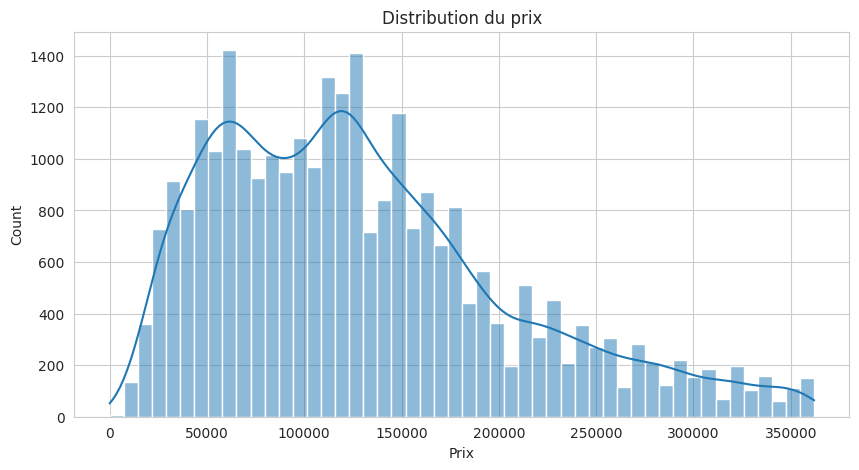

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(v1['Prix'], bins=50, kde=True)
plt.title('Distribution du prix')
plt.show()

**▪ Relation Prix – Kilométrage**

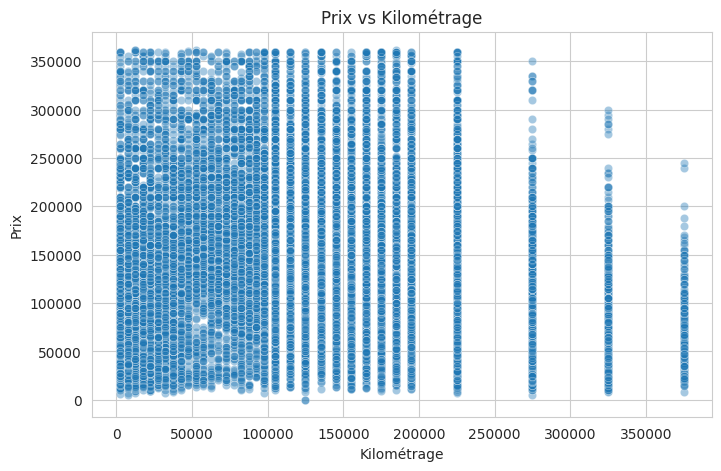

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=v1['Kilométrage'], y=v1['Prix'], alpha=0.4)
plt.title('Prix vs Kilométrage')
plt.show()

**▪ Matrice de corrélation**

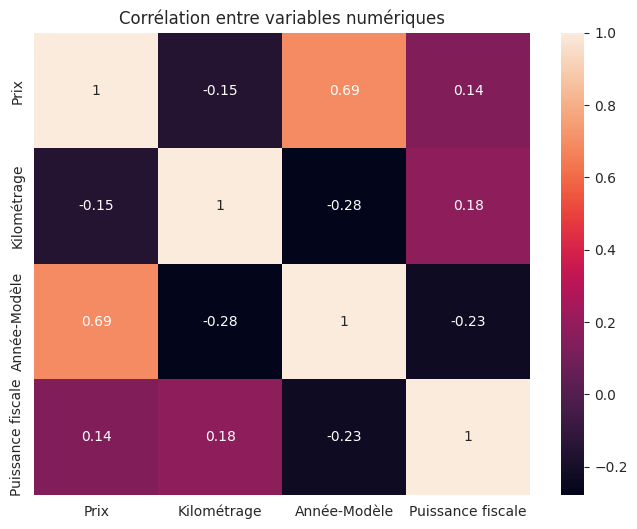

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(v1[['Prix','Kilométrage','Année-Modèle','Puissance fiscale']].corr(), annot=True)
plt.title('Corrélation entre variables numériques')
plt.show()

# Partie 11 : Encodage final

In [ ]:
# Encodage en 0/1
v1['Première main'] = v1['Première main'].map({'Oui': 1, 'Non': 0})

v1['Boite de vitesses'] = v1['Boite de vitesses'].map({'Manuelle': 0, 'Automatique': 1})

#frequency encoding
fuel_freq = v1['Type de carburant'].value_counts(normalize=True)
v1['Carburant_encoded'] = v1['Type de carburant'].map(fuel_freq)


# Initialiser l'encodeur
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Appliquer le one-hot encoding
Origine_encoded = encoder.fit_transform(v1[['Origine']])

# Créer un DataFrame avec des noms de colonnes explicites
Origine_v1 = pd.DataFrame(Origine_encoded, columns=encoder.get_feature_names_out(['Origine']))

# Réindexer pour éviter les problèmes d'alignement
Origine_v1.index = v1.index

# Concaténer avec le DataFrame original
v1 = pd.concat([v1, Origine_v1], axis=1)


#ordinal encoding
etat_mapping = {
    'Mauvais': 0,
    'Moyen': 1,
    'Très bon': 2,
    'Neuf': 3
}
v1['État_encoded'] = v1['État'].map(etat_mapping)

# Partie 12 : Sauvegarde du dataset final

In [ ]:
v1.to_csv("model_version.csv", index=False)

In [ ]:
v1.columns()